In [11]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
from ariel_pred.dataset import DataLoaderAndCalibrator
from ariel_pred.preprocessing import SGSmoothing
from ariel_pred.plots import plot_white_curve
from ariel_pred.transit import FunctionFittingBasedPhaseDetector
from ariel_pred.models import TransitMultiplicationFactorFinder, SValuesCNN, SValuesCNNTrainer
from ariel_pred.features import WavelengthsGroupsMultiplierFinder
from ariel_pred.metrics import score, gll
from ariel_pred.sigma import OGSignalVarBasedSigmaCalculator
from ariel_pred.modeling.s_values_cnn_with_star_info import SValuesCNNWithStarInfoModel, SValuesCNNWithStarInfoTrainer
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import random
from scipy.optimize import minimize
from tqdm.auto import tqdm
import pandas as pd
import torch
from torch import nn
import scipy

In [13]:
data_loader = DataLoaderAndCalibrator(
    data_path=Path("../data/raw"),
    output_path=Path("../data/calibrated/full"),
    force_recalibration=False,
    cut_airs_channels=True,
    binning=4,
    n_jobs=4
)
train_data, train_labels = data_loader.load_all_train_data()
train_data.shape, train_labels.shape

Loading calibrated train data...


((1100, 1406, 283), (1100, 283))

In [14]:
features_extractor = WavelengthsGroupsMultiplierFinder()

features = features_extractor.extract_features(
    train_data,
    average_cross_groups=False,
    wavelengths_groups=[1, 2, 4, 8, 16, 32, 64],
    weights=[1, 1, 1, 1, 1, 1, 1]
)

features.shape

  0%|          | 0/1100 [00:00<?, ?it/s]

(1100, 283, 7)

In [15]:
spectrum = np.load("../models/s_values_cnn_with_star_info_res/s_values_cnn_with_star_info_val_preds.npy")
spectrum.shape

(1100, 283)

In [16]:
sigma_calculator = OGSignalVarBasedSigmaCalculator(
    mean_fgs_sigma = 9.0e-4,
    mean_airs_sigma = 6.0e-4,
    fgs_min_sigma = 1e-6,
    airs_min_sigma = 1e-6,
)
sigma = sigma_calculator.get_sigma(train_data)
gll(np.concatenate([spectrum, sigma], axis=1), train_labels)

  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating FGS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

0.394389894866441

In [17]:
def cost_function(params, x, mu):
    sigma = params[0]
    return (0.5 * (np.log(2 * np.pi) + np.log(sigma**2) + ((x - mu)**2) / (sigma**2))).mean()

optimal_sigma = np.zeros(spectrum.shape[0])

for i in tqdm(range(spectrum.shape[0])):
    res = minimize(cost_function, [0.00068], args=(train_labels[i], spectrum[i]), bounds=[(1e-6, 0.01)])
    optimal_sigma[i] = res.x[0]

  0%|          | 0/1100 [00:00<?, ?it/s]

In [18]:
optimal_sigma.shape

(1100,)

In [21]:
features_for_sigma = np.zeros((features.shape[0], 1))

In [22]:
spectrum_std = np.std(spectrum, axis=1, keepdims=True)
spectrum_mean = np.mean(spectrum, axis=1, keepdims=True)


In [25]:
smoother = SGSmoothing(window_size=150, poly_order=2)
transit_finder = FunctionFittingBasedPhaseDetector()
smoothed_white_curves = np.zeros((train_data.shape[0], train_data.shape[1]))
for i in range(train_data.shape[0]):
    smoothed_white_curves[i] = smoother.smooth(train_data[i, :, 1:].mean(axis=1))
transit_locations = transit_finder.phase_detect_multiple_planets(
    smoothed_white_curves
)

  0%|          | 0/1100 [00:00<?, ?it/s]

In [26]:
def get_airs_sigma(data: np.ndarray, transit_locations: np.ndarray, mean_airs_sigma: float=5.5e-4, airs_min_sigma: float=1e-6, eps=1e-12) -> np.ndarray:
        airs_sigma = np.zeros(data.shape[0])

        for i in tqdm(range(data.shape[0]), desc="Calculating AIRS sigma"):
            signal = data[i]
            t1, t2, t3, t4 = transit_locations[i]

            airs = signal[:, 1:].mean(axis=1)

            oot = np.concatenate([airs[:t1], airs[t4:]], axis=0)
            inn = airs[t2:t3]

            var_oot = np.var(oot)
            var_inn = np.var(inn)
            oot_mean = np.mean(oot)

            airs_sigma[i] = np.sqrt((var_inn / len(inn) + var_oot / len(oot)).mean()) / max(
                oot_mean, eps
            )

        airs_sigma_scaled = airs_sigma / np.mean(airs_sigma) * mean_airs_sigma
        airs_sigma_scaled = airs_sigma_scaled.clip(min=airs_min_sigma)
        return airs_sigma_scaled
    
airs_sigma = get_airs_sigma(train_data, transit_locations, mean_airs_sigma=5.5e-4, airs_min_sigma=1e-6)
airs_sigma.shape

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

(1100,)

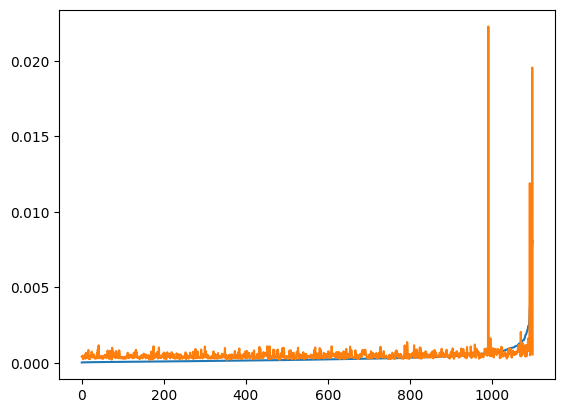

In [29]:
plt.plot(np.sort(optimal_sigma), label="Optimal sigma")
plt.plot(airs_sigma[np.argsort(optimal_sigma)], label="AIRS sigma")
plt.show()

In [30]:
sigma_features = np.concatenate([spectrum_mean, spectrum_std, airs_sigma[:, np.newaxis]], axis=1)
sigma_features.shape

(1100, 3)

In [32]:
np.sqrt(((optimal_sigma - airs_sigma)**2).mean())

(np.float64(0.0009254843397632171), np.float64(0.0005797339133722931))

In [37]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error

X = sigma_features.copy()
y = optimal_sigma.copy()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_preds = np.zeros_like(y)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X)):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
    regression = LinearRegression()
    regression.fit(X_train, y_train)
    val_preds = regression.predict(X_val)
    cv_preds[val_idx] = val_preds
    score = root_mean_squared_error(y_val, val_preds)
    cv_scores.append(score)
    print(f"Fold {fold+1} RMSE: {score:.6f}")

print(f"Mean CV RMSE: {np.mean(cv_scores):.6f}")
cv_preds

Fold 1 RMSE: 0.000240
Fold 2 RMSE: 0.000824
Fold 3 RMSE: 0.000554
Fold 4 RMSE: 0.000468
Fold 5 RMSE: 0.000472
Mean CV RMSE: 0.000512


array([3.60692066e-04, 9.68552847e-05, 9.05057570e-04, ...,
       1.10469712e-04, 2.87053112e-04, 2.59021555e-04], shape=(1100,))

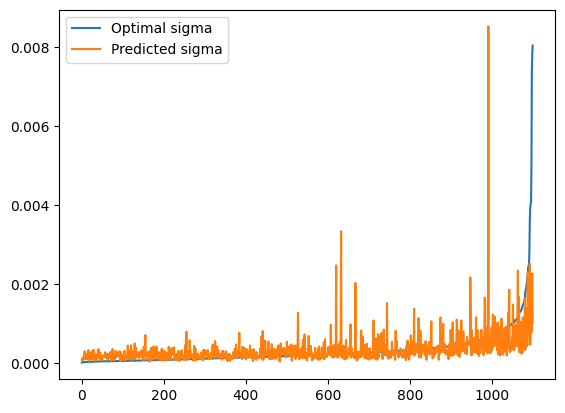

In [38]:
plt.plot(np.sort(optimal_sigma), label="Optimal sigma")
plt.plot(cv_preds[np.argsort(optimal_sigma)], label="Predicted sigma")
plt.legend()
plt.show()

In [39]:
cv_preds.shape

(1100,)

In [60]:
model_sigma = np.repeat(cv_preds[:, np.newaxis], 283, axis=1)
model_sigma_mean = model_sigma.mean()
model_sigma[:, 0] = model_sigma[:, 0] / model_sigma_mean * 9.0e-4
model_sigma[:, 1:] = model_sigma[:, 1:] / model_sigma_mean * 5.5e-4
gll(np.concatenate([spectrum, model_sigma.clip(1e-5)], axis=1), train_labels)

0.4208458135435906

In [54]:
old_sigma_calculator = OGSignalVarBasedSigmaCalculator(
    mean_fgs_sigma = 9.0e-4,
    mean_airs_sigma = 5.5e-4,
    fgs_min_sigma = 1e-6,
    airs_min_sigma = 1e-6,
)
old_sigma = old_sigma_calculator.get_sigma(train_data)
gll(np.concatenate([spectrum, old_sigma], axis=1), train_labels)

  0%|          | 0/1100 [00:00<?, ?it/s]

Calculating FGS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

Calculating AIRS sigma:   0%|          | 0/1100 [00:00<?, ?it/s]

0.3968818916256378

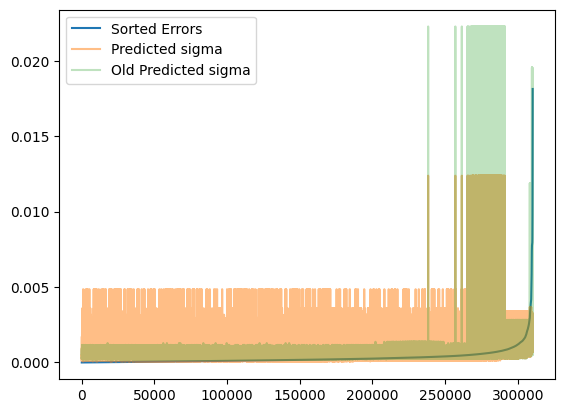

In [58]:
flat_airs_errors = np.abs(spectrum[:, 1:] - train_labels[:, 1:]).flatten()
flat_airs_sigma = model_sigma[:, 1:].flatten()
old_flat_airs_sigma = old_sigma[:, 1:].flatten()

plt.plot(np.sort(flat_airs_errors), label="Sorted Errors")
plt.plot(flat_airs_sigma[np.argsort(flat_airs_errors)], label="Predicted sigma", alpha=0.5)
plt.plot(old_flat_airs_sigma[np.argsort(flat_airs_errors)], label="Old Predicted sigma", alpha=0.3)
plt.legend()
plt.show()

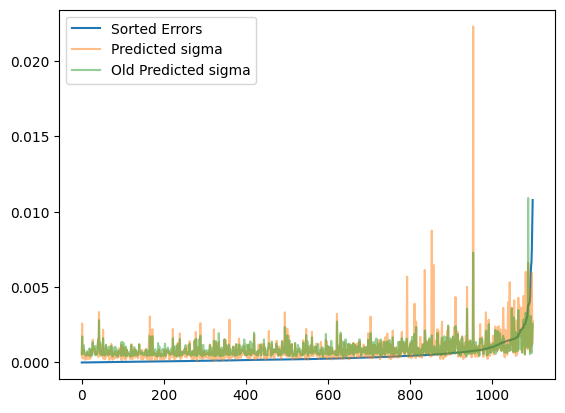

In [56]:
flat_fgs_errors = np.abs(spectrum[:, 0] - train_labels[:, 0]).flatten()
flat_fgs_sigma = model_sigma[:, 0].flatten()
old_flat_fgs_sigma = old_sigma[:, 0].flatten()

plt.plot(np.sort(flat_fgs_errors), label="Sorted Errors")
plt.plot(flat_fgs_sigma[np.argsort(flat_fgs_errors)], label="Predicted sigma", alpha=0.5)
plt.plot(old_flat_fgs_sigma[np.argsort(flat_fgs_errors)], label="Old Predicted sigma", alpha=0.5)
plt.legend()
plt.show()